# BESS Optimal Scheduling — Arbitrage, Degradation & Bankability

*Optimal day-ahead scheduling of a grid-connected battery + PV plant: a linear program, solved
twice (Gurobi and an open-source fallback), pushed past "does the LP solve" into the questions
that actually decide whether a battery project gets built.*

> This notebook grew out of an optimization exercise in DTU course **46765 – Machine Learning
> for Energy Systems**. The baseline formulation in Section 3.1 (charge/discharge/state-of-charge
> arbitrage, PV forced through the battery) follows that exercise. Everything from Section 3.2
> onward — the extended formulation, degradation modelling, project economics, stochastic
> scheduling, and the open-source reproducibility check — was built independently. See the
> [Acknowledgements](#Acknowledgements--References) section at the end.

## Roadmap

| # | Section | Status |
|---|---|---|
| 1 | Problem & motivation | ✅ |
| 2 | Data: real day-ahead prices (CC-BY, cached) + synthetic PV generator | ✅ |
| 3 | Mathematical formulation — baseline + extended | ✅ |
| 4 | Baseline model (faithful to the course formulation) | ✅ |
| 5 | Extended model: direct PV sale, curtailment, degradation cost in the objective | ✅ |
| 6 | Multi-day backtest | ✅ |
| 7 | Battery cycling & degradation analysis (throughput **and** depth-of-discharge aware) | ✅ (v1) |
| 8 | Project economics: CAPEX sweep → NPV, IRR, LCOS, break-even CAPEX | ✅ (v1) |
| 9 | Reproducibility: identical LP solved with an open-source solver (PuLP/CBC) | ✅ |
| 10 | Stochastic scheduling under price & PV scenarios (the course's optional, unsolved extension) | ✅ |
| 11 | Roadmap: rolling-horizon backtest, revenue stacking, calibrated degradation curves, price forecasting | 📋 |

✅ implemented · 📋 future work (Section 11 explains the reasoning behind each).


## 1 - Problem Description

Battery Energy Storage Systems (BESS) can participate in electricity markets by buying energy
when prices are low and selling it when prices are high. By shifting energy consumption and
production over time, the BESS can exploit price variations while also supporting the
integration of renewable generation such as PV. However, the battery has limited energy
capacity, charging/discharging power, and efficiency losses. Therefore, the BESS must determine
when to charge and discharge to maximize its market revenue while respecting its physical
operating constraints.

That much is the course exercise. But "maximize market revenue" is an incomplete objective for
an actual investment decision, for three reasons this notebook tries to address head-on:

1. **Cycling wears the battery out**, and not uniformly — a shallow 20→40% swing and a deep
   0→100% swing move the same energy but do not age a lithium-ion cell by the same amount. An
   optimizer that only sees EUR/MWh arbitrage margin has no way to know that.
2. **Nobody agrees on what a battery costs installed.** Rather than picking one CAPEX figure
   and hoping it's right, Section 8 sweeps it and asks: at what installed cost (EUR/MWh) does
   this battery's arbitrage revenue actually pay for itself?
3. **Prices and PV are not known in advance.** Section 10 quantifies how much that uncertainty
   is worth, by comparing a single day-ahead schedule against the (unrealistic, upper-bound)
   case of knowing the future exactly.

We use a deterministic day-ahead price forecast (Sections 4–9) and a set of explicit scenarios
(Section 10) to compute optimal 24-hour BESS schedules and understand how optimization,
degradation-awareness and project economics fit together to support a real bidding & investment
decision.


### BESS Day-Ahead Scheduling Problem

We consider a Battery Energy Storage System (BESS) participating in the day-ahead electricity
market. The optimization horizon is one day with a 15-minute time resolution:
$T = 24 \times 4 = 96$ time intervals, with $\Delta t = 0.25\ \text{h}$.


## 2 - Data

Two data sources feed the model, chosen so the whole project stays legally clean and
reproducible by anyone who clones the repository (important for a public, pinned project):

- **Day-ahead prices** — real data, fetched from Energinet's [Energi Data
  Service](https://www.energidataservice.dk/) API and cached locally as CSV. This data is
  published under **CC-BY 4.0**: free to reuse and redistribute, including commercially, with
  attribution ("Source: Energinet, www.energidataservice.dk").
- **PV production** — the course exercise points to DTU's *EnergyDataDK* platform for measured
  PV series. That platform's general terms restrict redistribution/commercial use unless a
  dataset's specific license says otherwise, and the license on the particular "Production -
  Solar" export used while developing this exercise wasn't established. Rather than risk
  publishing data I don't have clear rights to redistribute, `bess_opt.data.synthetic_pv_profile`
  generates a **synthetic but physically-motivated** PV profile (clear-sky solar-geometry shape ×
  randomised daily cloudiness × cloud-transient noise). Full reasoning in `data/README.md`. As a
  bonus, unlike a fixed measured file, this generator can produce as much data as the backtest or
  the scenario analysis need.


In [1]:
import sys
from pathlib import Path

SRC_DIR = Path.cwd() / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bess_opt.data import fetch_spot_prices, synthetic_pv_profile, make_price_scenarios
from bess_opt.model import BatteryParams, build_bess_lp, build_bess_lp_extended, build_bess_lp_stochastic
from bess_opt.model_opensource import solve_bess_lp_extended_opensource
from bess_opt.degradation import equivalent_full_cycles, dod_half_cycles, degradation_cost_eur
from bess_opt.economics import npv, irr, lcos, capex_breakeven_sweep, find_breakeven_capex
from bess_opt.backtest import solve_day, run_multi_day_backtest, sample_available_days
from bess_opt.plotting import set_style, plot_price_and_pv, plot_soc, plot_charge_discharge, plot_profit_by_day, plot_capex_breakeven

set_style()
%matplotlib inline


Prices: 33,884 records, 2025-10-01 00:00:00 to 2026-09-18 23:45:00  (mean 100.1, std 58.1 EUR/MWh)


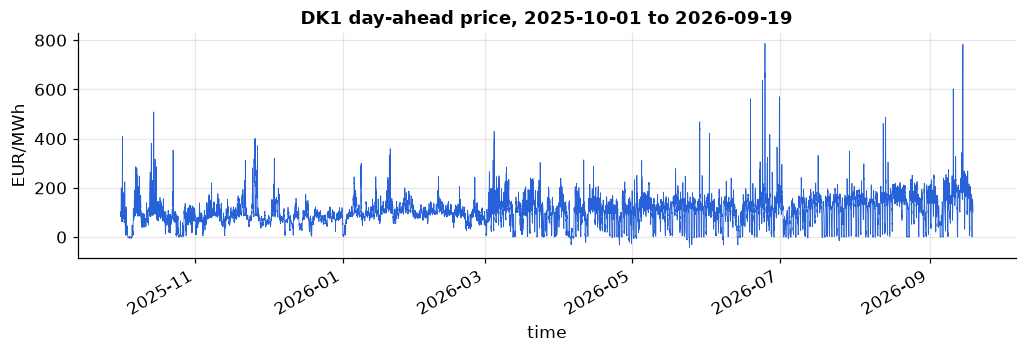

In [2]:
# Real day-ahead prices, DK1, 15-minute resolution - fetched once, cached as CSV from then on.
PRICE_START, PRICE_END, PRICE_AREA = "2025-10-01", "2026-09-19", "DK1"
PRICE_CACHE = Path("data") / "spot_prices_dk1.csv"

prices = fetch_spot_prices(PRICE_START, PRICE_END, price_area=PRICE_AREA, cache_path=PRICE_CACHE)
print(f"Prices: {len(prices):,} records, {prices.index.min()} to {prices.index.max()}  "
      f"(mean {prices.mean():.1f}, std {prices.std():.1f} EUR/MWh)")
prices.plot(figsize=(11, 3), color="#2661D8", linewidth=0.5, title=f"DK1 day-ahead price, {PRICE_START} to {PRICE_END}")
plt.ylabel("EUR/MWh")
plt.show()


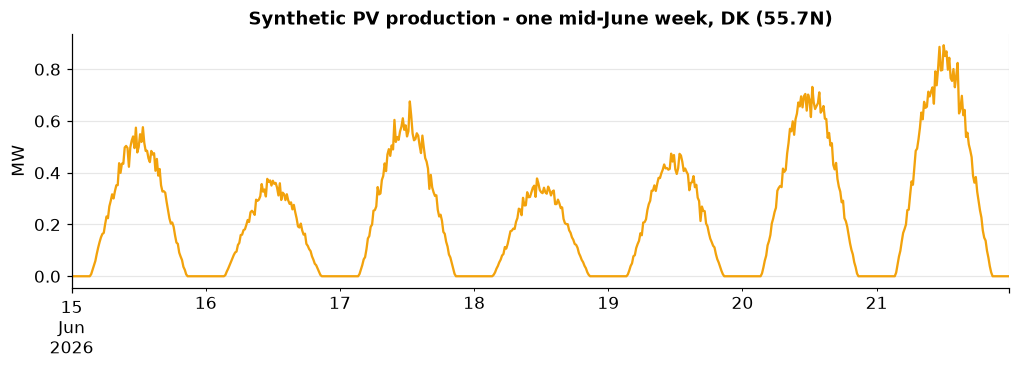

In [3]:
# Synthetic PV: one illustrative week, to sanity-check the seasonal/diurnal shape before trusting it further.
PV_CAPACITY_MW = 1.0
demo_index = pd.date_range("2026-06-15", periods=7 * 96, freq="15min")
pv_demo = synthetic_pv_profile(demo_index, capacity_mw=PV_CAPACITY_MW, seed=0)

pv_demo.plot(figsize=(11, 3), color="#F2A20C", title="Synthetic PV production - one mid-June week, DK (55.7N)")
plt.ylabel("MW")
plt.show()


## 3 - Problem Formulation

### 3.1 - Baseline formulation (course exercise)

**Decision variables**, for each time interval $t$:
- $P_t^{\mathrm{ch}}$: power purchased from the market to charge the BESS $[\text{MW}]$
- $P_t^{\mathrm{dis}}$: power sold to the market by discharging the BESS $[\text{MW}]$
- $E_t$: energy stored in the BESS at the beginning of interval $t$ $[\text{MWh}]$

**Objective:**
$$
\operatorname*{maximize}_{\{P_t^{\mathrm{ch}},\,P_t^{\mathrm{dis}},\,E_t\}_{t=1}^{T}}
\qquad
\sum_{t=1}^{T} p_t \left( P_t^{\mathrm{dis}} - P_t^{\mathrm{ch}} \right)\Delta t
$$

**Constraints:**
1. Energy balance tracking the state of charge over the horizon, with *all* available PV power
   routed through the battery:
   $$E_{t+1} = E_t + \eta^{\mathrm{ch}}\left(P_t^{\mathrm{ch}} + P_t^{\mathrm{PV}}\right)\Delta t - \frac{P_t^{\mathrm{dis}}}{\eta^{\mathrm{dis}}}\Delta t$$
2. $0 \le P_t^{\mathrm{ch}} \le P_{\max}^{\mathrm{ch}}$, $\quad 0 \le P_t^{\mathrm{dis}} \le P_{\max}^{\mathrm{dis}}$
3. $0 \le E_t \le E_{\max}$
4. $E_0 = E_{\mathrm{init}}$ (we start the day at 50% state of charge)

Implemented in [`bess_opt.model.build_bess_lp`](src/bess_opt/model.py).


### 3.2 - Extended formulation

The baseline forces *every* watt of PV through the battery, taking an unavoidable
$\eta^{\mathrm{ch}} < 1$ round-trip loss even when the battery has no room, and gives the
optimizer no way to simply sell PV directly to the grid or curtail it when neither storing nor
selling is worthwhile (e.g. a moment of negative prices with a full battery). It also has no
notion that cycling the battery has a cost.

We add three new variables per interval — direct PV sale $P_t^{\mathrm{PV,direct}}$, PV routed
to the battery $P_t^{\mathrm{PV,batt}}$, and PV curtailment $P_t^{\mathrm{PV,curt}}$ — and a
degradation cost coefficient $c_{\mathrm{degr}}$ [EUR / MWh throughput]:

$$
\operatorname*{maximize}
\quad
\underbrace{\sum_{t=1}^{T} p_t \left( P_t^{\mathrm{dis}} + P_t^{\mathrm{PV,direct}} - P_t^{\mathrm{ch}} \right)\Delta t}_{\text{market revenue}}
\;-\;
\underbrace{c_{\mathrm{degr}} \sum_{t=1}^{T} \left(P_t^{\mathrm{ch}} + P_t^{\mathrm{dis}}\right)\Delta t}_{\text{degradation cost}}
$$

subject to the same power/energy limits as before, the revised energy balance

$$E_{t+1} = E_t + \eta^{\mathrm{ch}} \left(P_t^{\mathrm{ch}} + P_t^{\mathrm{PV,batt}}\right)\Delta t - \frac{P_t^{\mathrm{dis}}}{\eta^{\mathrm{dis}}}\Delta t$$

and the PV split constraint

$$P_t^{\mathrm{PV,direct}} + P_t^{\mathrm{PV,batt}} + P_t^{\mathrm{PV,curt}} = P_t^{\mathrm{PV}}$$

Still a linear program — the degradation term is linear in throughput, which is exactly the
simplification Section 7 revisits (it can't distinguish a shallow cycle from a deep one; a
convex piecewise-linear, depth-aware version of this same term is on the roadmap in Section 11).
Implemented in [`bess_opt.model.build_bess_lp_extended`](src/bess_opt/model.py); a
solver-agnostic, Gurobi-license-free replica lives in
[`bess_opt.model_opensource`](src/bess_opt/model_opensource.py) and is used in Section 9.


## 4 - Baseline model

Solve the exact course formulation for one representative day, as a reference point for
everything that follows.


In [4]:
battery = BatteryParams(e_max_mwh=4.0, p_ch_max_mw=2.0, p_dis_max_mw=2.0, eta_ch=0.97, eta_dis=0.97)
dt = 0.25
DAY = pd.Timestamp("2026-05-15")

t_steps = round(24 / dt)
day_index = pd.date_range(DAY, periods=t_steps, freq=pd.Timedelta(hours=dt))
prices_day = prices.reindex(day_index)
assert not prices_day.isna().any(), "missing price data for the chosen day - pick another DAY"

pv_day = synthetic_pv_profile(day_index, capacity_mw=PV_CAPACITY_MW, seed=42)

model_base, schedule_base = build_bess_lp(day_index, prices_day.to_numpy(), pv_day.to_numpy(), dt, battery)
print(f"Baseline model status: {model_base.Status} (2 = optimal)")
print(f"Baseline market profit: {model_base.ObjVal:,.2f} EUR")


Restricted license - for non-production use only - expires 2027-11-29


Baseline model status: 2 (2 = optimal)
Baseline market profit: 1,160.28 EUR


## 5 - Extended model

Same day, extended formulation, no degradation cost yet ($c_{\mathrm{degr}} = 0$) so the two
models are directly comparable: the extended model has strictly more freedom (it can always
fall back to routing PV through the battery and never selling directly), so it should never do
worse.


In [5]:
model_ext, schedule_ext = build_bess_lp_extended(
    day_index, prices_day.to_numpy(), pv_day.to_numpy(), dt, battery,
    degradation_eur_per_mwh_throughput=0.0,
)
print(f"Extended model status: {model_ext.Status} (2 = optimal)")
print(f"Extended market profit: {model_ext.ObjVal:,.2f} EUR")
print(f"Baseline market profit: {model_base.ObjVal:,.2f} EUR")
print(f"Gain from direct PV sale + curtailment flexibility: {model_ext.ObjVal - model_base.ObjVal:,.2f} EUR "
      f"({(model_ext.ObjVal / model_base.ObjVal - 1):.1%})")
assert model_ext.ObjVal >= model_base.ObjVal - 1e-6

schedule_ext.head()


Extended model status: 2 (2 = optimal)
Extended market profit: 1,186.35 EUR
Baseline market profit: 1,160.28 EUR
Gain from direct PV sale + curtailment flexibility: 26.07 EUR (2.2%)


,time,price,P_pv,P_ch,P_dis,E,E_end,P_pv_direct,P_pv_curt,P_pv_to_batt
0,2026-05-15 00:00:00,139.000000,0.0,0.0,2.00,2.000000,1.484536,0.0,0.0,0.0
1,2026-05-15 00:15:00,132.649994,0.0,0.0,2.00,1.484536,0.969072,0.0,0.0,0.0
2,2026-05-15 00:30:00,129.559998,0.0,0.0,1.76,0.969072,0.515464,0.0,0.0,0.0
3,2026-05-15 00:45:00,124.389999,0.0,0.0,0.00,0.515464,0.515464,0.0,0.0,0.0
4,2026-05-15 01:00:00,133.419998,0.0,0.0,2.00,0.515464,0.000000,0.0,0.0,0.0


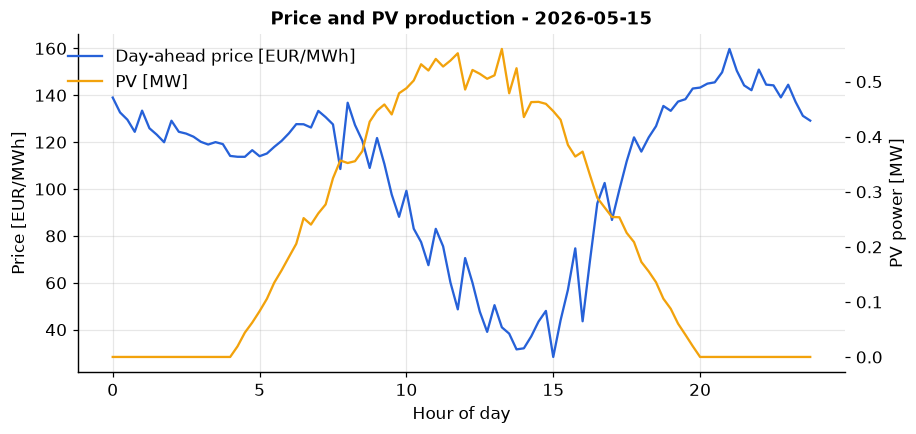

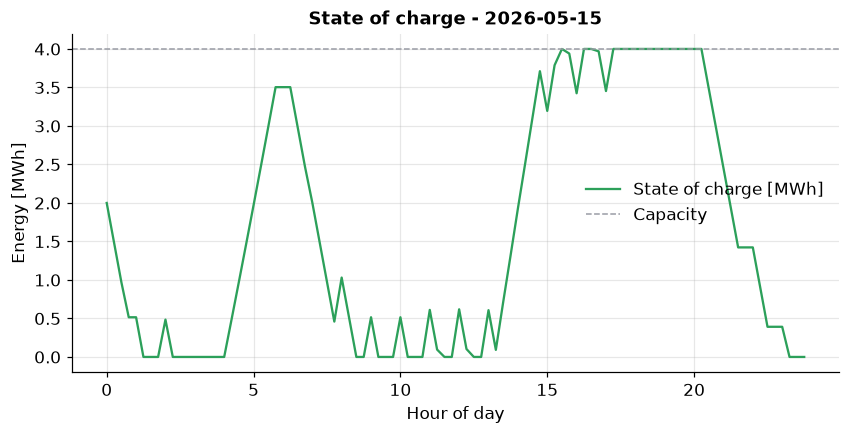

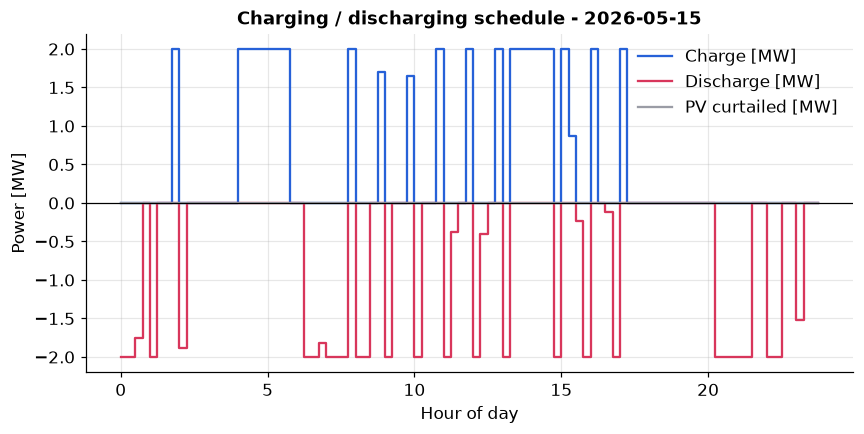

In [6]:
plot_price_and_pv(schedule_ext, f"Price and PV production - {DAY.date()}")
plt.show()

plot_soc(schedule_ext, battery.e_max_mwh, f"State of charge - {DAY.date()}")
plt.show()

plot_charge_discharge(schedule_ext, f"Charging / discharging schedule - {DAY.date()}")
plt.show()


## 6 - Multi-day backtest

Prices and PV vary a lot day to day. Solving one day tells us about that one day; solving many
random days (each independently, full-information, battery resetting to 50% SoC every morning)
tells us about the *distribution* of achievable arbitrage value - what the rest of this notebook
(degradation, economics) is built on.


In [7]:
N_DAYS = 30
sample_days = sample_available_days(prices, n_days=N_DAYS, dt=dt, seed=32)

results, schedules = run_multi_day_backtest(
    sample_days, prices, dt, battery, pv_capacity_mw=PV_CAPACITY_MW, degradation_eur_per_mwh_throughput=0.0,
)
print(f"Solved {len(results)}/{N_DAYS} requested days.")
results.describe().T


Solved 30/30 requested days.


,count,mean,std,min,25%,50%,75%,max
profit_eur,30.0,1154.165938,491.864456,492.813499,774.896707,1096.442254,1404.005550,2696.545163
mean_price,30.0,103.186830,35.702618,23.986146,83.410911,95.562240,121.900651,176.573958
price_std,30.0,43.289808,26.254030,6.857170,21.911706,44.085791,56.667724,140.908801
pv_energy_mwh,30.0,4.637248,1.906383,1.786893,3.407588,4.768083,5.429916,8.556466
charged_mwh,30.0,10.355224,3.439783,5.887836,8.514327,9.650029,11.740653,24.221010
discharged_mwh,30.0,12.586044,3.169793,7.858009,10.491812,12.009383,14.201611,24.805111
equivalent_full_cycles,30.0,2.867659,0.823698,1.751731,2.355225,2.667751,3.239649,6.128265


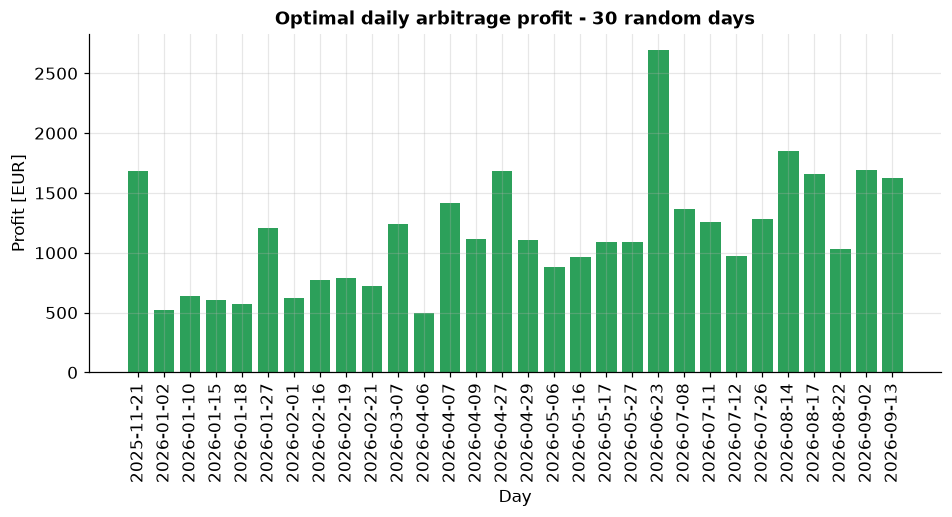

Mean daily profit: 1,154 EUR/day (median 1,096, std 492)
Mean equivalent full cycles/day: 2.87


In [8]:
plot_profit_by_day(results, f"Optimal daily arbitrage profit - {len(results)} random days")
plt.show()

print(f"Mean daily profit: {results['profit_eur'].mean():,.0f} EUR/day "
      f"(median {results['profit_eur'].median():,.0f}, std {results['profit_eur'].std():,.0f})")
print(f"Mean equivalent full cycles/day: {results['equivalent_full_cycles'].mean():.2f}")


Profit should track price *volatility*, not just its level: a flat high-price day gives the
battery nothing to arbitrage, while a volatile day - cheap morning, expensive evening - does,
regardless of the average level. Let's check.


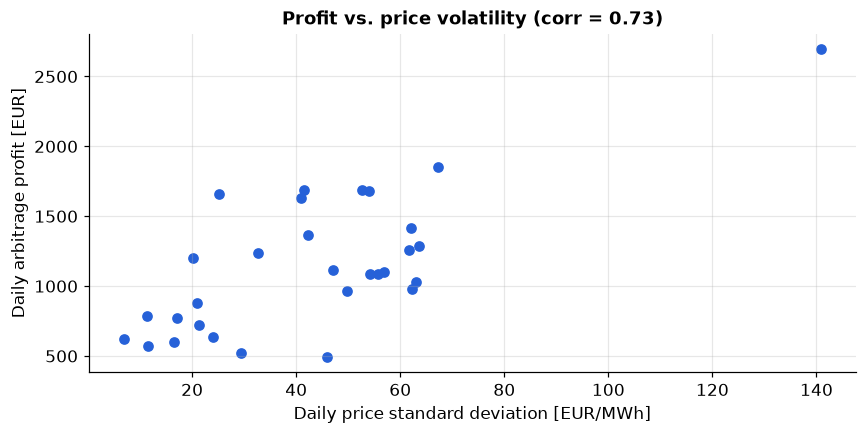

Correlation between daily profit and price volatility: 0.73


In [9]:
corr = results["profit_eur"].corr(results["price_std"])
fig, ax = plt.subplots()
ax.scatter(results["price_std"], results["profit_eur"], color="#2661D8")
ax.set_xlabel("Daily price standard deviation [EUR/MWh]")
ax.set_ylabel("Daily arbitrage profit [EUR]")
ax.set_title(f"Profit vs. price volatility (corr = {corr:.2f})")
plt.show()
print(f"Correlation between daily profit and price volatility: {corr:.2f}")


## 7 - Battery cycling & degradation analysis

Two ways to look at how hard the battery worked on the reference day from Section 5:

- **Throughput-only** (`equivalent_full_cycles`): total energy moved ÷ 2·E_max. This is exactly
  what the linear `degradation_eur_per_mwh_throughput` cost term in Section 3.2's objective can
  see.
- **Depth-of-discharge-aware** (`dod_half_cycles`): every local up/down swing in the state-of-
  charge trajectory, individually. This is what the throughput-only metric is blind to - it
  can't tell ten shallow 15% swings from one deep 90% swing, even though real cells age
  differently under the two.


Equivalent full cycles on 2026-05-15: 3.26
Number of half-cycles (individual SoC swings): 28
Mean depth of discharge per half-cycle: 25.0%


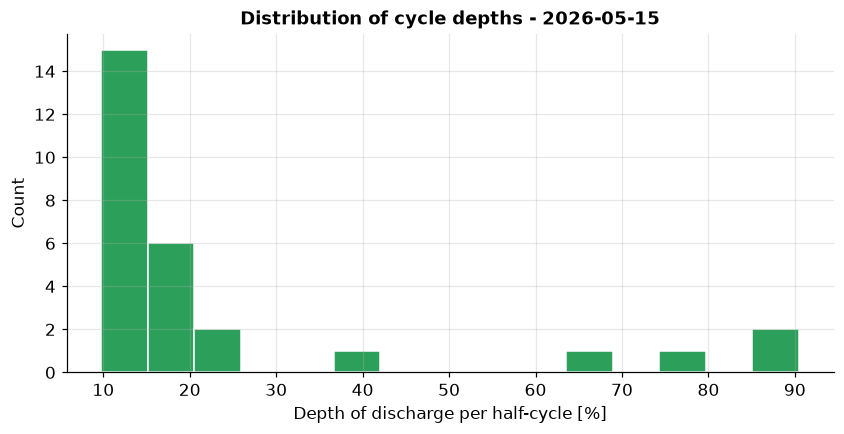

In [10]:
cycles_ext = equivalent_full_cycles(schedule_ext, battery.e_max_mwh, dt)
half_cycles = dod_half_cycles(schedule_ext, battery.e_max_mwh)

print(f"Equivalent full cycles on {DAY.date()}: {cycles_ext:.2f}")
print(f"Number of half-cycles (individual SoC swings): {len(half_cycles)}")
print(f"Mean depth of discharge per half-cycle: {half_cycles['depth_of_discharge'].mean():.1%}")

fig, ax = plt.subplots()
ax.hist(half_cycles["depth_of_discharge"] * 100, bins=15, color="#2CA05A", edgecolor="white")
ax.set_xlabel("Depth of discharge per half-cycle [%]")
ax.set_ylabel("Count")
ax.set_title(f"Distribution of cycle depths - {DAY.date()}")
plt.show()


Turning cycles into EUR needs a battery price. Assuming a representative 4,000 full-equivalent-
cycle lifetime at 80% reference DoD (a common Li-ion NMC/LFP datasheet figure) and a CAPEX of
150,000 EUR/MWh, compare what the throughput-only metric charges against the DoD-aware one -
same day, same total energy moved, different implied cost, because *how* it was cycled differs.


In [11]:
degr = degradation_cost_eur(schedule_ext, battery.e_max_mwh, dt, capex_eur_per_mwh=150_000)
for k, v in degr.items():
    print(f"{k:28s}: {v:,.3f}" if isinstance(v, float) else f"{k:28s}: {v}")

pct_diff = (degr["dod_aware_cost_eur"] / degr["throughput_only_cost_eur"] - 1)
print(f"\nDoD-aware cost is {pct_diff:+.1%} relative to the throughput-only estimate on this day.")


equivalent_full_cycles      : 3.260
n_half_cycles               : 28
mean_depth_of_discharge     : 0.250
throughput_only_cost_eur    : 488.982
dod_aware_cost_eur          : 655.039
cost_per_full_cycle_eur     : 150.000

DoD-aware cost is +34.0% relative to the throughput-only estimate on this day.


How does the optimizer itself react once cycling has a price? Re-solving the same day at a few
different values of $c_{\mathrm{degr}}$ shows the schedule getting visibly less "choppy" as
degradation cost rises - the model starts leaving low-value cycles on the table rather than
chasing every last spread.


In [12]:
degr_costs = [0.0, 2.0, 5.0, 10.0, 20.0]
sweep_rows = []
for c in degr_costs:
    m, s = build_bess_lp_extended(day_index, prices_day.to_numpy(), pv_day.to_numpy(), dt, battery,
                                    degradation_eur_per_mwh_throughput=c)
    sweep_rows.append({
        "degradation_eur_per_mwh": c,
        "market_profit_eur": (s["price"] * (s["P_dis"] + s["P_pv_direct"] - s["P_ch"]) * dt).sum(),
        "net_objective_eur": m.ObjVal,
        "equivalent_full_cycles": equivalent_full_cycles(s, battery.e_max_mwh, dt),
    })
degr_sweep = pd.DataFrame(sweep_rows)
degr_sweep


,degradation_eur_per_mwh,market_profit_eur,net_objective_eur,equivalent_full_cycles
0,0.0,1186.349829,1186.349829,3.259878
1,2.0,1182.304843,1138.755128,2.721857
2,5.0,1156.636661,1086.329745,1.757673
3,10.0,1128.861275,1028.690605,1.252133
4,20.0,1103.045343,939.670508,1.021093


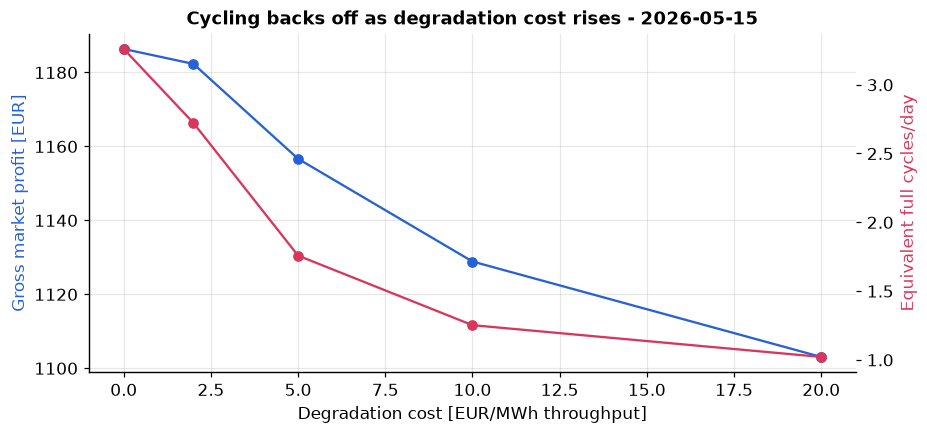

In [13]:
fig, ax1 = plt.subplots()
ax1.plot(degr_sweep["degradation_eur_per_mwh"], degr_sweep["market_profit_eur"], "o-", color="#2661D8", label="Gross market profit")
ax1.set_xlabel("Degradation cost [EUR/MWh throughput]")
ax1.set_ylabel("Gross market profit [EUR]", color="#2661D8")
ax2 = ax1.twinx()
ax2.plot(degr_sweep["degradation_eur_per_mwh"], degr_sweep["equivalent_full_cycles"], "o-", color="#D8365B", label="Equivalent full cycles")
ax2.set_ylabel("Equivalent full cycles/day", color="#D8365B")
ax2.grid(False)
ax1.set_title(f"Cycling backs off as degradation cost rises - {DAY.date()}")
plt.show()


## 8 - Project economics: is this bankable?

We don't know a real battery's installed cost, so instead of guessing one, we **sweep** it and
ask the question an investor actually asks: *given the arbitrage revenue this battery earns
(Section 6's backtest), up to what CAPEX does the project break even?*

Assumptions (deliberately simple, listed so they're easy to challenge and refine later, see
Section 11): flat annual revenue extrapolated from the daily backtest mean, OPEX as a fixed % of
CAPEX/year, throughput-based degradation cost (Section 7) scaled to annual cycling, no
augmentation/replacement over the project life.


Extrapolated annual arbitrage revenue: 421,271 EUR/yr
Extrapolated annual equivalent full cycles: 1,047 cycles/yr

Break-even battery CAPEX (arbitrage-only revenue): ~262,670 EUR/MWh


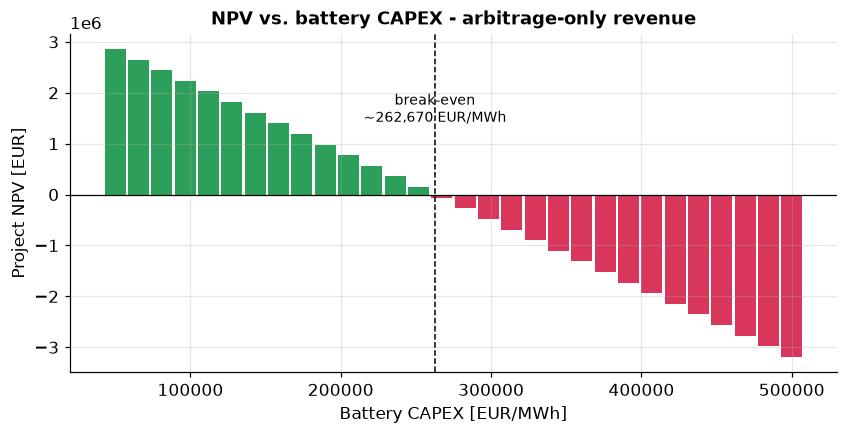

In [14]:
DISCOUNT_RATE = 0.06
LIFETIME_YEARS = 12
CYCLE_LIFE_AT_REF_DOD = 4000.0
OPEX_PCT_OF_CAPEX = 0.02

annual_arbitrage_revenue_eur = results["profit_eur"].mean() * 365
annual_equivalent_cycles = results["equivalent_full_cycles"].mean() * 365
print(f"Extrapolated annual arbitrage revenue: {annual_arbitrage_revenue_eur:,.0f} EUR/yr")
print(f"Extrapolated annual equivalent full cycles: {annual_equivalent_cycles:,.0f} cycles/yr")

capex_range = np.linspace(50_000, 500_000, 30)
sweep = capex_breakeven_sweep(
    annual_arbitrage_revenue_eur, annual_equivalent_cycles, battery.e_max_mwh,
    DISCOUNT_RATE, LIFETIME_YEARS, capex_range,
    cycle_life_at_reference_dod=CYCLE_LIFE_AT_REF_DOD, opex_pct_of_capex=OPEX_PCT_OF_CAPEX,
)
breakeven_capex = find_breakeven_capex(sweep)
print(f"\nBreak-even battery CAPEX (arbitrage-only revenue): ~{breakeven_capex:,.0f} EUR/MWh")

plot_capex_breakeven(sweep, breakeven_capex)
plt.show()


In [15]:
example_capex = 150_000  # EUR/MWh - roughly mid-range for a utility-scale Li-ion BESS today
row = sweep.iloc[(sweep["capex_eur_per_mwh"] - example_capex).abs().idxmin()]
example_lcos = lcos(
    example_capex, battery.e_max_mwh,
    annual_opex_eur=OPEX_PCT_OF_CAPEX * example_capex * battery.e_max_mwh,
    annual_discharged_mwh=results["discharged_mwh"].mean() * 365,
    discount_rate=DISCOUNT_RATE, lifetime_years=LIFETIME_YEARS,
)
print(f"At {example_capex:,.0f} EUR/MWh CAPEX:")
print(f"  NPV               : {row['npv_eur']:,.0f} EUR")
print(f"  IRR               : {row['irr']:.1%}")
print(f"  Simple payback    : {row['payback_years']:.1f} years")
print(f"  LCOS              : {example_lcos:.1f} EUR/MWh discharged")


At 150,000 EUR/MWh CAPEX:
  NPV               : 1,607,692 EUR
  IRR               : 44.9%
  Simple payback    : 2.2 years
  LCOS              : 18.2 EUR/MWh discharged


## 9 - Reproducibility: solving without a Gurobi license

Gurobi needs a license - even the free academic one requires a university network/account and
periodic renewal, a poor fit for a public repo other people might want to actually run.
[`bess_opt.model_opensource`](src/bess_opt/model_opensource.py) reproduces the *exact same*
extended LP with [PuLP](https://coin-or.github.io/pulp/) and the open-source CBC solver it
ships with. Solving the Section 5 day both ways should give (numerically) identical objectives.


In [16]:
obj_opensource, schedule_opensource = solve_bess_lp_extended_opensource(
    day_index, prices_day.to_numpy(), pv_day.to_numpy(), dt, battery, degradation_eur_per_mwh_throughput=0.0,
)
print(f"Gurobi extended objective       : {model_ext.ObjVal:,.4f} EUR")
print(f"PuLP/CBC extended objective     : {obj_opensource:,.4f} EUR")
print(f"Absolute difference             : {abs(model_ext.ObjVal - obj_opensource):.2e} EUR")
assert abs(model_ext.ObjVal - obj_opensource) < 1e-2, "Gurobi and open-source solutions should match"
print("\nMatch confirmed - the rest of this project's results do not depend on holding a Gurobi license.")


Gurobi extended objective       : 1,186.3498 EUR
PuLP/CBC extended objective     : 1,186.3498 EUR
Absolute difference             : 1.86e-06 EUR

Match confirmed - the rest of this project's results do not depend on holding a Gurobi license.


## 10 - Stochastic scheduling under price & PV uncertainty

The original course exercise poses this as an optional, unsolved extension: in practice, prices
and PV are not known with certainty when the day-ahead schedule must be committed. Instead of a
single deterministic day, consider $S$ scenarios, each a possible realization of the day-ahead
price and PV, and choose **one** schedule (exactly as a real day-ahead bid must be - it cannot
depend on which scenario materializes) that maximizes expected profit:

$$\max \sum_{s=1}^{S} \pi_s \, \mathrm{Profit}_s$$

Implemented in [`bess_opt.model.build_bess_lp_stochastic`](src/bess_opt/model.py): `Pch`, `Pdis`
are shared across scenarios (the day-ahead commitment); the state of charge is necessarily
scenario-indexed, since it is driven by that scenario's own PV realization. PV curtailment is
*also* scenario-indexed - unlike the market commitment, curtailing is a real-time decision that
can react to the PV actually realized, and without that flexibility a single shared
charge/discharge trajectory can easily be infeasible across scenarios whose PV differs enough
(no amount of shared discharging can always make room for every scenario's PV).

To put a number on what this uncertainty costs, we use two classic stochastic-programming
benchmarks:

- **RP** (*recourse problem*): the expected profit of the single here-and-now schedule above.
- **WS** (*wait-and-see*): solve the ordinary deterministic model separately for each scenario
  (as if we knew that scenario would happen) and average the results - an unrealistic upper
  bound, since no real bid can be scenario-specific.
- **EVPI** $= WS - RP \ge 0$: the *expected value of perfect information* - how much a perfect
  day-ahead crystal ball would be worth, in EUR/day, relative to committing to one schedule now.


In [17]:
N_SCENARIOS = 3
price_scenarios = make_price_scenarios(prices_day.to_numpy(), n_scenarios=N_SCENARIOS, seed=7)
pv_scenarios = {s: synthetic_pv_profile(day_index, capacity_mw=PV_CAPACITY_MW, seed=1000 + s).to_numpy()
                for s in price_scenarios}

model_stoch, schedules_stoch, shared_schedule = build_bess_lp_stochastic(
    day_index, price_scenarios, pv_scenarios, dt, battery,
)
RP = model_stoch.ObjVal
print(f"RP (expected profit of the single day-ahead schedule): {RP:,.2f} EUR")

ws_profits = []
for s, scen in price_scenarios.items():
    m_s, _ = build_bess_lp(day_index, scen["prices"], pv_scenarios[s], dt, battery)
    ws_profits.append(m_s.ObjVal)
WS = float(np.mean(ws_profits))
print(f"WS (average of per-scenario perfect-foresight profits): {WS:,.2f} EUR")

EVPI = WS - RP
print(f"\nEVPI = WS - RP = {EVPI:,.2f} EUR/day "
      f"({EVPI / RP:.1%} of the day-ahead-committed expected profit)")


RP (expected profit of the single day-ahead schedule): 1,027.78 EUR
WS (average of per-scenario perfect-foresight profits): 1,185.57 EUR

EVPI = WS - RP = 157.79 EUR/day (15.4% of the day-ahead-committed expected profit)


## 11 - Roadmap: what's next

Deliberately left open, with enough scaffolding already in place (`bess_opt.data`,
`bess_opt.model`, `bess_opt.degradation`, `bess_opt.economics`) that each item below is an
extension of existing modules, not a rewrite:

- **Rolling-horizon backtest with forecast error.** Section 6 solves each day with perfect
  foresight of that day's own prices/PV. A realistic deployment re-optimizes on a rolling
  window using a *forecast* (with error) and only commits the next step - `bess_opt.backtest`
  already separates "build one day's schedule" from "loop over days," which is the natural seam
  to add this at.
- **Revenue stacking.** Add a simplified frequency-reserve (FCR/aFRR) capacity revenue stream
  alongside arbitrage, with the associated power de-rating (capacity reserved for reserves isn't
  available for arbitrage) - a second linear term in the same objective, and a new constraint
  linking reserved and arbitrage power.
- **Calibrated, endogenous degradation.** Section 7's DoD-stress curve is illustrative, not
  fitted to data. Calibrating it to a real cell datasheet or a public dataset (e.g.
  [BatteryArchive](https://www.batteryarchive.org/)), and then embedding it *inside* the LP as a
  convex piecewise-linear cost (rather than the current post-hoc, throughput-only linear term)
  would let the optimizer trade off arbitrage revenue against degradation directly, instead of
  only through the blunt `degradation_eur_per_mwh_throughput` coefficient.
- **Full rainflow cycle counting.** `dod_half_cycles` uses a simplified peak-valley scheme
  that's exact for the smooth, single-pass SoC trajectories this project produces, but doesn't
  handle nested/interrupted cycles the way full rainflow counting does - worth revisiting if a
  rolling-horizon or revenue-stacking extension produces noisier trajectories.
- **Price forecasting.** This same course's `02-sklearn-exercises.ipynb` builds regression
  models on this kind of energy time series - a natural full-circle extension is feeding a
  forecasting model's predictions (and, ideally, its predictive uncertainty) into the rolling
  horizon and stochastic-scenario machinery already built here, instead of the synthetic
  perturbation scenarios used in Section 10.
- **Real measured PV.** Swap in a real, legally-obtained PV CSV via `data/raw_pv/` (already
  git-ignored) the moment a clearly-licensed dataset is available - see `data/README.md`.


## Acknowledgements & References

- Problem statement and baseline formulation (Section 3.1): DTU course *46765 - Machine
  Learning for Energy Systems*, BESS day-ahead scheduling exercise.
- Day-ahead price data: Energinet, [Energi Data
  Service](https://www.energidataservice.dk/tso-electricity/DayAheadPrices), CC-BY 4.0.
- Everything else in this notebook (extended formulation, degradation and economics modules,
  the open-source reproducibility check, and the stochastic-scheduling implementation) was
  developed independently for this project - see `README.md` for the full repository writeup.
